<a href="https://colab.research.google.com/github/AI-Linguist/Pruebas-/blob/main/Imageclassifier_4_Maryam_Ghaderi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from keras.utils import to_categorical
from tensorflow.keras import layers, models, Input
from keras import layers, models
from keras.layers import Input  # Also add this if you're using Input()
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import cv2
import glob


In [ ]:

from keras.datasets import cifar10
from sklearn.preprocessing import LabelBinarizer
import numpy as np

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Normalize pixel values (0–255 → 0–1)
#X_train, X_test = X_train / 255.0, X_test / 255.0
# 1. preprocess data
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# One-hot encode labels (10 classes)
lb = LabelBinarizer()
y_train = lb.fit_transform(y_train)
y_test = lb.transform(y_test)


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [ ]:
# 2. Data augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

In [ ]:
# 3. Define CNN model
from keras import models, layers
from keras.layers import Input
import tensorflow as tf
def cnnModel():
    model = models.Sequential([
        Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn = cnnModel()
cnn.fit(X_train, y_train, batch_size=32, epochs=10, validation_data=(X_test, y_test))





Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.3396 - loss: 1.7989 - val_accuracy: 0.5895 - val_loss: 1.1439
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5928 - loss: 1.1540 - val_accuracy: 0.6629 - val_loss: 0.9564
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6603 - loss: 0.9592 - val_accuracy: 0.7088 - val_loss: 0.8270
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7080 - loss: 0.8281 - val_accuracy: 0.7323 - val_loss: 0.7605
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7388 - loss: 0.7435 - val_accuracy: 0.7429 - val_loss: 0.7296
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7642 - loss: 0.6678 - val_accuracy: 0.7690 - val_loss: 0.6695
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7801 - loss: 0.6182 - val_accuracy: 0.7663 - val_loss: 0.6739
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7996 - loss: 0.5626

In [ ]:
# 4. Train with early stopping
early_stop = EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True)

final_model = cnn.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=100,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.6930 - loss: 0.8823 - val_accuracy: 0.7605 - val_loss: 0.7086
Epoch 2/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.7194 - loss: 0.8083 - val_accuracy: 0.7794 - val_loss: 0.6315
Epoch 3/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7254 - loss: 0.7919 - val_accuracy: 0.7785 - val_loss: 0.6496
Epoch 4/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.7308 - loss: 0.7706 - val_accuracy: 0.7738 - val_loss: 0.6600
Epoch 5/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7386 - loss: 0.7476 - val_accuracy: 0.7842 - val_loss: 0.6357
Epoch 6/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7448 - loss: 0.7300 - val_accuracy: 0.7662 - val_loss: 0.6789
Epoch 7/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.7454 - loss: 0.7262 - val_accuracy: 0.7801 - val_loss: 0.6460
Epoch 8/100
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.7592 - los

In [ ]:
# 5. Evaluate
test_loss, test_accuracy = cnn.evaluate(X_test, y_test)
print(f"Test accuracy: {test_accuracy:.4f}, Test loss: {test_loss:.4f}")

# 6. Save model
cnn.save("cifar10_model.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8392 - loss: 0.4860
Test accuracy: 0.8410, Test loss: 0.4746


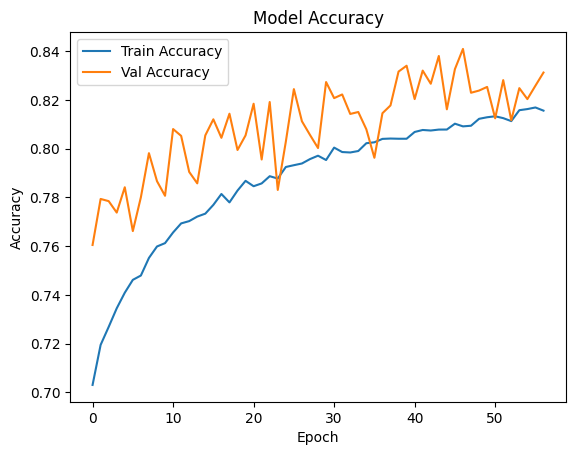

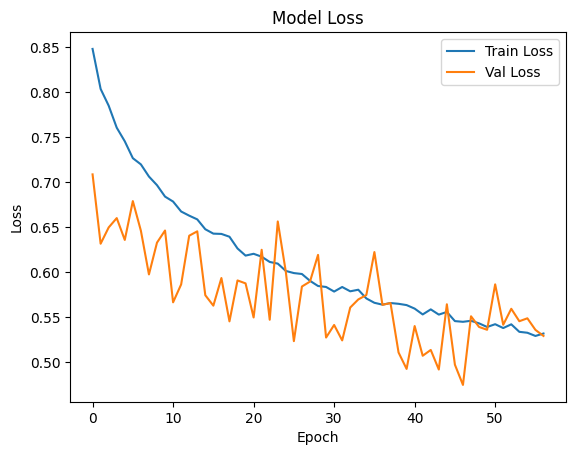

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(final_model.history['accuracy'], label='Train Accuracy')
plt.plot(final_model.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

# Plot loss
plt.plot(final_model.history['loss'], label='Train Loss')
plt.plot(final_model.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


In [ ]:
#from google.colab import files
#files.download("cifar10_model.keras")

import os
os.listdir()



['.config', 'cifar10_model.keras', 'sample_data']

In [ ]:
cnn.save("cifar10_model.keras")


In [ ]:
from google.colab import files
files.download("cifar10_model.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>